# Práctica 5 - Distribución Normal y Teorema de De Moivre-Laplace

**Licenciatura en Matemáticas Aplicadas, UAM-C**  
**UEA:** Probabilidad II  
**Trimestre:** 26P  
**Grupo:** CF01MA  
**Profesora** Daniela Aguirre Guerrero

---

## Objetivos

- Comprender las propiedades fundamentales de la distribución normal.
- Graficar la función de densidad de probabilidad (PDF) y la función de distribución acumulada (CDF).
- Calcular probabilidades utilizando la distribución normal.
- Determinar la esperanza y la varianza de una variable aleatoria normal.
- Comprender el Teorema de De Moivre-Laplace.
- Aproximar una distribución binomial mediante una distribución normal.
- Comparar resultados teóricos y simulados utilizando Python.

La distribución normal es una de las distribuciones más importantes en probabilidad y estadística. Muchas variables observadas en la naturaleza y en procesos industriales presentan comportamientos aproximadamente normales.

Además, la distribución normal permite aproximar otras distribuciones, como la binomial, mediante el Teorema de De Moivre-Laplace.



## Preparación del entorno


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

# Ajustes de visualización
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['font.size'] = 12

# 1. Distribución Normal

Una variable aleatoria continua $X$ sigue una distribución normal con parámetros $\mu_X$ y $\sigma_X$ si su función de densidad está dada por

$$
f(x)=\frac{1}{\sigma_X\sqrt{2\pi}}
e^{-\frac{(x-\mu_X)^2}{2\sigma_X^2}}
$$

donde:

- $\mu_X$ representa la media.
- $\sigma_X$ representa la desviación estándar.

## 1.1 Función de densidad de probabilidad de una distribución normal

La gráfica de esta distribución tiene forma de campana y es simétrica respecto a la media.

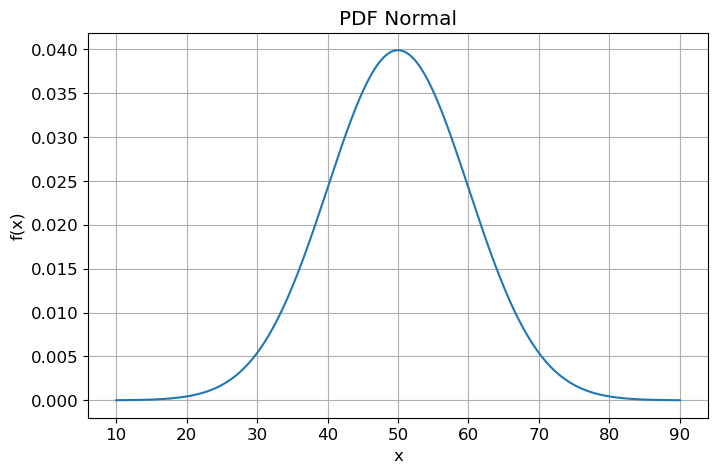

In [49]:
mu = 50
sigma = 10

x = np.linspace(10,90,1000)

pdf = stats.norm.pdf(x,mu,sigma)

plt.plot(x,pdf)
plt.title("PDF Normal")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

## Actividades

### Responde las siguientes preguntas

- ¿Cómo cambia la forma de la curva cuando aumenta σ?
- ¿Qué pasa con la curva cuando $\mu$ cambia?

### Gráfica de la PDF de variablea normal estándar

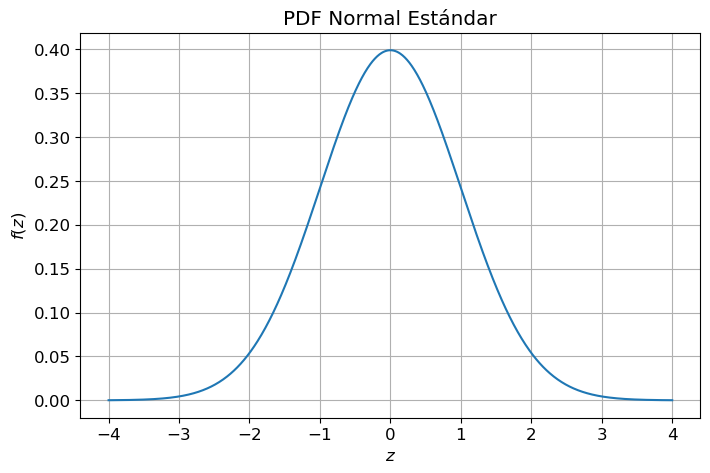

In [50]:
mu_e = 0
sigma_e = 1

x = np.linspace(-4,4,1000)

pdf = stats.norm.pdf(x,mu_e,sigma_e)

plt.plot(x,pdf)
plt.title("PDF Normal Estándar")
plt.xlabel("$z$")
plt.ylabel("$f(z)$")
plt.grid()
plt.show()

## 1.2 Función de probabilidad acumulada de una distribución normal

La función de distribución acumulada se define como

$$
F(x)=P(X\le x)=\Phi(x)
$$

y representa la probabilidad acumulada hasta el valor \(x\).

### Gráfica de la CDF de variable normal

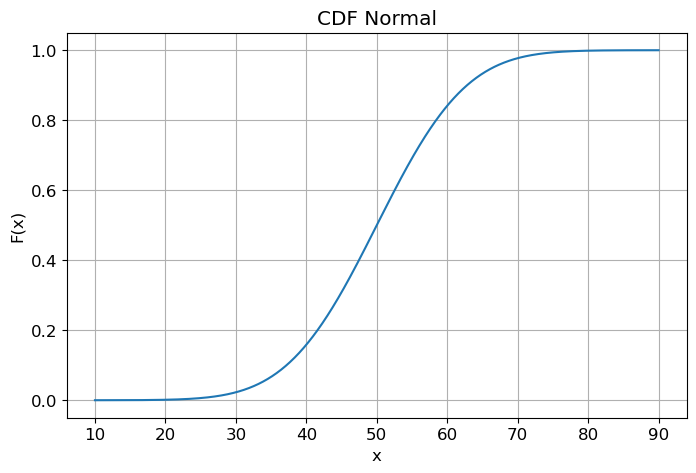

In [93]:
mu = 50
sigma = 10

x = np.linspace(10,90,1000)

cdf = stats.norm.cdf(x,mu,sigma)

plt.plot(x,cdf)

plt.title("CDF Normal")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.grid()
plt.show()

## Actividades

### Gráfica de la CDF de variable normal estándar

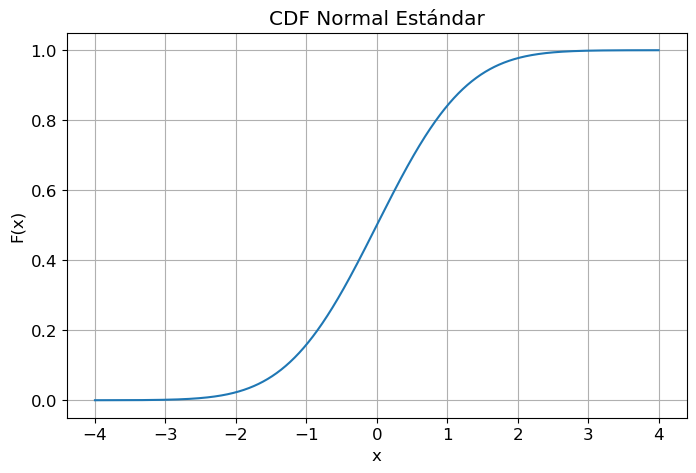

In [52]:
mu = 0
sigma = 1

x = np.linspace(-4,4,1000)

cdf = stats.norm.cdf(x,mu,sigma)

plt.plot(x,cdf)

plt.title("CDF Normal Estándar")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.grid()
plt.show()

# 2. Cálculo de probablidades

Sea $X$ una v.a. normal con parámetros $\mu_X=70$ y $\sigma_X=100$. Calcula la probabilidad $P(X<80)$.

### Cálculo

In [64]:
x0 = 80  # punto de evaluación

mu = 70
sigma = 100

p = stats.norm.cdf(80,mu,sigma)

print(p)

0.539827837277029


### Visualización

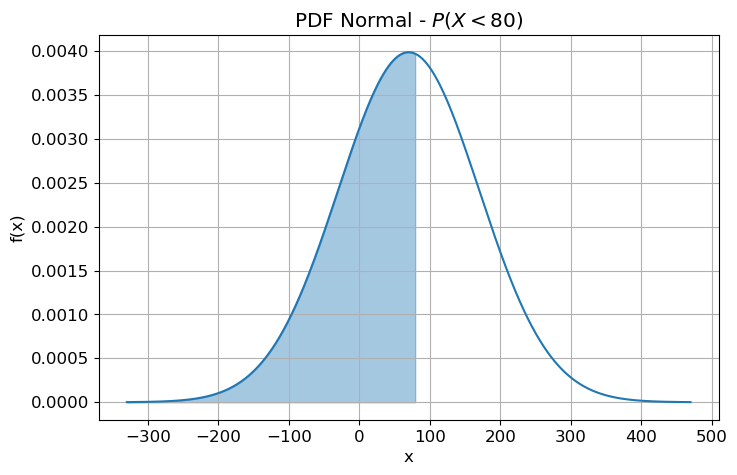

In [65]:
x = np.linspace(mu-4*sigma,mu+4*sigma,1000)

pdf = stats.norm.pdf(x,mu,sigma)

plt.plot(x,pdf)

mask = x <= x0
plt.fill_between(x[mask], pdf[mask], alpha=0.4, color='C0')

plt.title("PDF Normal - $P(X<80)$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

# 3. Estandarización

La función de distribución normal estándar, denotada por $Z$, es un caso especial de la función donde $\mu_Z=0$ y $\sigma_Z=1$, entonces:

$$
f(z)=\frac{1}{\sqrt{2\pi}}
e^{-\frac{z^2}{2}}
$$

Una de las propiedades más importantes de la distribución normal es que cualquier variable normal $X$ con parámeteros $\mu_X$ y $\sigma_X$ puede transformarse en una normal estándar mediante:

$$
Z=\frac{X-\mu_X}{\sigma_X}
$$

Esta transformación permite utilizar tablas de la distribución normal estándar para calcular probabilidades de la siguiente manera

$$
P(X<a) = P(Z<\frac{a-\mu_X}{\sigma_X})
$$

## Cálculo de probabilidades aplicando estandarización

Sea $X$ una v.a. normal con parámetros $\mu_X=70$ y $\sigma_X=100$. Calcula la probabilidad $P(X<80)$, entonces

$$
P(X<80) = P(Z<\frac{80-70}{100}) =P(Z<0.1)
$$



In [68]:
z0 = 0.1  # punto de evaluación
mu=0
sigma = 1

p = stats.norm.cdf(z0,mu,sigma)

print(p)

0.539827837277029


## Visualización

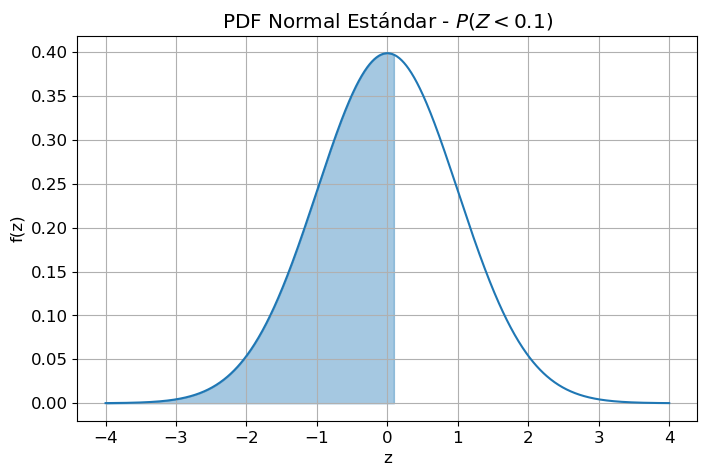

In [69]:
z = np.linspace(mu-4*sigma,mu+4*sigma,1000)

pdf = stats.norm.pdf(z,mu,sigma)

plt.plot(z,pdf)

mask = z <= z0
plt.fill_between(z[mask], pdf[mask], alpha=0.4, color='C0')

plt.title("PDF Normal Estándar - $P(Z<0.1)$")
plt.xlabel("z")
plt.ylabel("f(z)")
plt.grid()
plt.show()

## 3.1 Ejercicio
Sea $X$ una v.a. normal con parámetros $\mu_X=70$ y $\sigma_X=100$. Calcula la probabilidad $P(60<X<85)$ con y sin estándarización. En ambos casos, gráfica la PDF sombreando el área correspondiente a la probablidad cálculada.

# 4. Teorema de De Moivre-Laplace

Sea $X$ una variable aleatoria Binomial con parámetros $n$, $p$. Cuando el número de ensayos $n$ es suficientemente grande, la distribución binomial puede aproximarse mediante una distribución normal con:

$$\mu=np$$

$$\sigma^2=np(1-p)$$

Por tanto,

Este resultado es conocido como el Teorema de De Moivre-Laplace y constituye un caso particular del Teorema Central del Límite.

## 4.1. Comparación entre una distribución binomial y una distribución normal

Considera una variable aleatoria binomial con parámetros $n=100$ y $p=0.5$. Ahora compararemos:

- La distribución binomial exacta.

In [81]:
n = 100
p = 0.5

k = np.arange(0,n+1)

binomial = stats.binom.pmf(k,n,p)

- La aproximación normal propuesta por el Teorema de De Moivre-Laplace.

In [82]:
mu = n*p

sigma = np.sqrt(n*p*(1-p))

normal = stats.norm.pdf(k,mu,sigma)

Graficamos simultáneamente:

- La función de masa de probabilidad de la distribución binomial.
- La función de densidad de la aproximación normal.

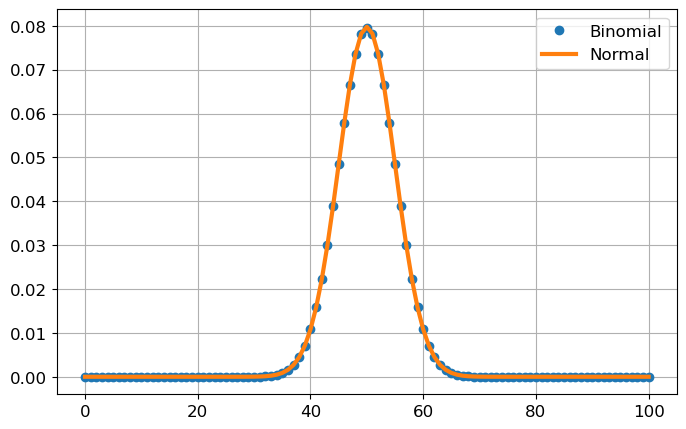

In [83]:
plt.plot(
    k,
    binomial,
    'o',
    label='Binomial'
)

plt.plot(
    k,
    normal,
    linewidth=3,
    label='Normal'
)

plt.legend()
plt.grid()

plt.show()

#### Aumenta el número de muestras n y observa como la aproximació  mejora

## 4.2 Corrección por continuidad

La distribución binomial es discreta mientras que la distribución normal es continua. Por esta razón, al aproximar probabilidades binomiales mediante una normal se utiliza la llamada corrección por continuidad. 

Por ejemplo: Sea X una v.a. binomal con  parámetros $n=100$ y $p=0.5$, entonces $X$ se puede aproximar a una v.a. normal $Y$ con parámetros $\mu_Y=np=50$ y $\sigma_Y^2=np(1-p)=25$.

$$
P(X≤60)≈P(Y≤60.5)
$$

Esta corrección suele mejorar significativamente la precisión de la aproximación.

### Resultado exacto

In [91]:
a=60
n=100
p=0.5 

p_exacta = stats.binom.cdf(a,n,p)

print(p_exacta)

0.9823998998911476


### Aproximación normal

In [92]:
mu = 50
sigma = 5

p_normal = stats.norm.cdf(60.5,mu,sigma)

print(p_normal)

0.9821355794371834


## 4.3 Simulación

En esta sección generaremos 10 000 observaciones de una distribución binomial. Posteriormente compararemos el histograma obtenido con la curva normal teórica correspondiente. Este experimento permite visualizar empíricamente el Teorema de De Moivre-Laplace.

In [94]:
# generaremos 10 000 observaciones de una distribución binomial
muestras = np.random.binomial(
    n=100,
    p=0.5,
    size=10000
)

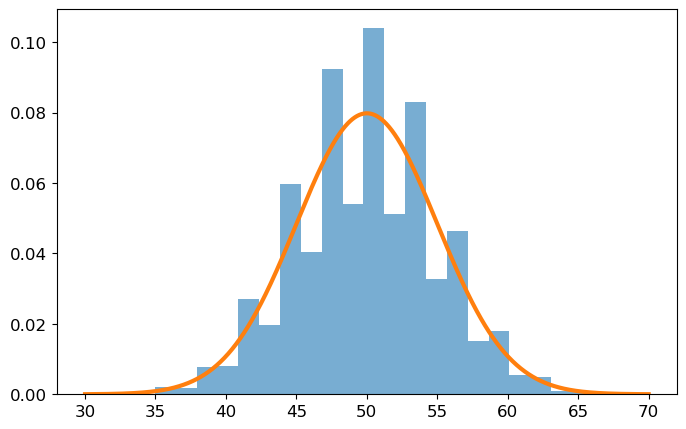

In [102]:
# Comparación con la curva normal teórica
plt.hist(
    muestras,
    bins=25,
    density=True,
    alpha=0.6
)

x = np.linspace(30,70,1000)

plt.plot(
    x,
    stats.norm.pdf(x,50,5),
    linewidth=3
)

plt.show()

### Pregunta
¿Cómo se relaciona este resultado con el Teorema de De Moivre-Laplace?

# 5. Ejercicio de aplicación

Una fábrica produce piezas electrónicas con una probabilidad de defecto de $p=0.1$. Se seleccionan aleatoriamente $n=200$ piezas.Sea

$$
X=\text{número de piezas defectuosas}
$$

Realice las siguientes actividades:

1. Calcula exactamente $P(X\le25)$ usado la v.a. binomial.
2. Utiliza el Teorema de De Moivre-Laplace para aproximar dicha probabilidad a una v.a. normal $Y$.
3. Calcula el error relativo de la aproximación $|P(X\le25)-P(Y\le25.5)|$.